Khoi Nguyen-Davis

Leaving comments for codes.

Problem 

In this exercise, you will use the Portuguese sea battles data that contains outcomes of naval battles between Portuguese and Dutch/British ships between 1583 and 1663.

In [7]:
import pandas as pd

url = "https://users.stat.ufl.edu/~winner/data/armada.dat"

sea_battle_df = pd.read_fwf(url)

# Rename columns for better readability and comprehension
columns = [
    "Battle",           
    "Year",             
    "Portuguese ships", 
    "Dutch ships",      
    "English ships",   
    "The ratio of Portuguese to Dutch/British ships", 
    "Spanish Involvement", # 1=Yes, 0=No
    "Portuguese outcome"   # -1=Defeat, 0=Draw, 1=Victory
]

sea_battle_df.columns = columns

print(sea_battle_df.head())
print(sea_battle_df.info())

           Battle  Year  Portuguese ships  Dutch ships  English ships  \
0  Malacca Strait  1606                14           11              0   
1   Ilha das Naus  1606                 6            9              0   
2      Pulo Butum  1606                 7            9              0   
3          Surrat  1615                 6            0              4   
4   Ilha das Naus  1615                 3            5              0   

   The ratio of Portuguese to Dutch/British ships  Spanish Involvement  \
0                                           1.273                    0   
1                                           0.667                    0   
2                                           0.778                    0   
3                                           1.500                    0   
4                                           0.600                    0   

   Portuguese outcome  
0                   0  
1                  -1  
2                   1  
3                   

In [8]:
sea_battle_df

,Battle,Year,Portuguese ships,Dutch ships,English ships,The ratio of Portuguese to Dutch/British ships,Spanish Involvement,Portuguese outcome
0,Malacca Strait,1606,14,11,0,1.273,0,0
1,Ilha das Naus,1606,6,9,0,0.667,0,-1
2,Pulo Butum,1606,7,9,0,0.778,0,1
3,Surrat,1615,6,0,4,1.500,0,0
4,Ilha das Naus,1615,3,5,0,0.600,0,-1
5,Jask,1620,4,0,4,1.000,0,0
6,Hormuz,1622,6,0,5,1.200,0,-1
7,Mogincoal Shoals,1622,4,4,2,0.667,0,-1
8,Hormuz,1625,8,4,4,1.000,0,0
9,Goa,1636,6,4,0,1.500,0,0


1. Use an SVM-based model to predict the Portuguese outcome of the battle from the number of ships involved on all sides and Spanish involvement.

Accuracy: 0.67
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80         5
           1       0.00      0.00      0.00         1

    accuracy                           0.67         6
   macro avg       0.40      0.40      0.40         6
weighted avg       0.67      0.67      0.67         6



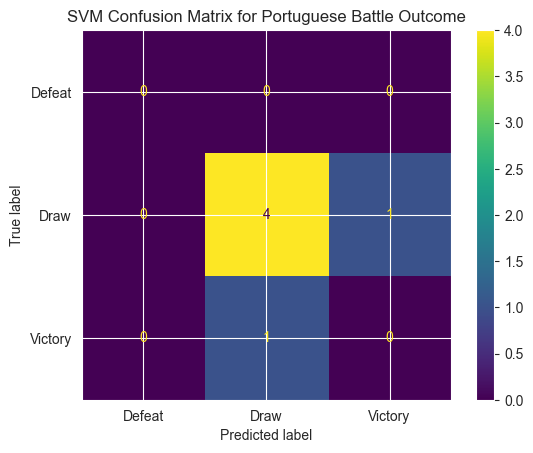

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X = sea_battle_df[["Portuguese ships", "Dutch ships", "English ships", "Spanish Involvement"]] # features of all ships involved in the battle
y = sea_battle_df["Portuguese outcome"]

# Split test size 0.2, random state 42 for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Support Vector Machine
svm = SVC(class_weight='balanced') # Use balanced class weights to handle class imbalances
svm.fit(X_train, y_train)

# Predict and evaluate the results
y_pred = svm.predict(X_test)
print("Accuracy: {:.2f}".format(accuracy_score(y_test, y_pred)))
print("Classification Report:\n", classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_estimator(
    svm,
    X_test,
    y_test,
    labels=[-1, 0, 1],  # Always show all possible classes since Portuguese outcome has 3 classes
    display_labels=["Defeat", "Draw", "Victory"]
)
plt.title("SVM Confusion Matrix for Portuguese Battle Outcome")
plt.show()

References:

Classifying data using Support Vector Machines (SVMs) in Python. (2025, August 02). Geeks For Geeks. Retrieved November 15, 2025, from https://www.geeksforgeeks.org/machine-learning/classifying-data-using-support-vector-machinessvms-in-python/

ConfusionMatrixDisplay. (2025). Scikit-Learn. Retrieved November 15, 2025, from https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html

Support Vector Machines. (2025). Scikit-Learn. Retrieved November 14, 2025, from https://scikit-learn.org/stable/modules/svm.html

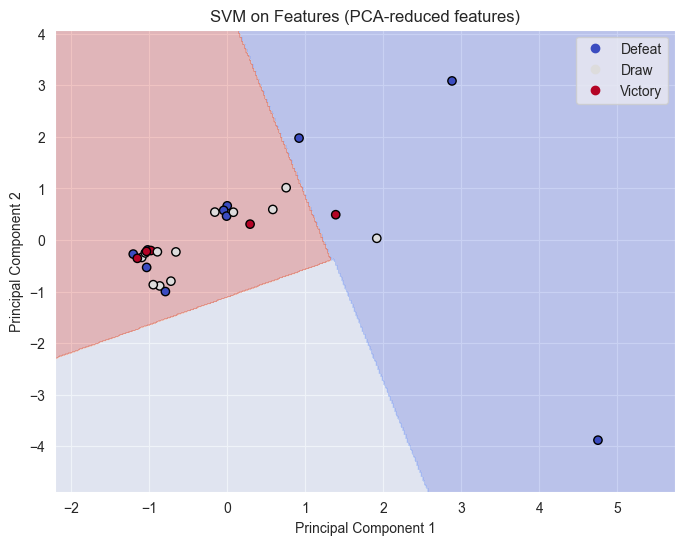

In [10]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = sea_battle_df[["Portuguese ships", "Dutch ships", "English ships", "Spanish Involvement"]].values
y = sea_battle_df["Portuguese outcome"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reduce to 2 principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Train SVM on PCA-reduced features
svm_pca = SVC(kernel='linear', class_weight='balanced')
svm_pca.fit(X_pca, y)

def plot_pca_decision_boundary(X, y, model): # Create a mesh grid for plotting the decision boundary
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1 # Add some padding to the min and max values for better visualization
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title("SVM on Features (PCA-reduced features)")
    plt.legend(handles=scatter.legend_elements()[0], labels=["Defeat", "Draw", "Victory"])
    plt.show()

plot_pca_decision_boundary(X_pca, y, svm_pca)

Reference:

More, Pravin. (2025, September 07). Principal Component Analysis (PCA) Explained Step by Step - With Python Code and Real-World Example. Medium. https://medium.com/@morepravin1989/principal-component-analysis-pca-explained-step-by-step-with-python-code-and-real-world-example-ff4e94c957a1 

Principal Comnponent Analysis with Python. (2025, July 11). Geeks For Geeks. Retrieved November 15, 2025, from https://www.geeksforgeeks.org/data-analysis/principal-component-analysis-with-python/

2. Try solving the same problem using two other classifiers that you know.

I am going to use random forest classifier and logistic regression.

Random Forest Accuracy: 0.17
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.20      0.29         5
           1       0.00      0.00      0.00         1

    accuracy                           0.17         6
   macro avg       0.25      0.10      0.14         6
weighted avg       0.42      0.17      0.24         6



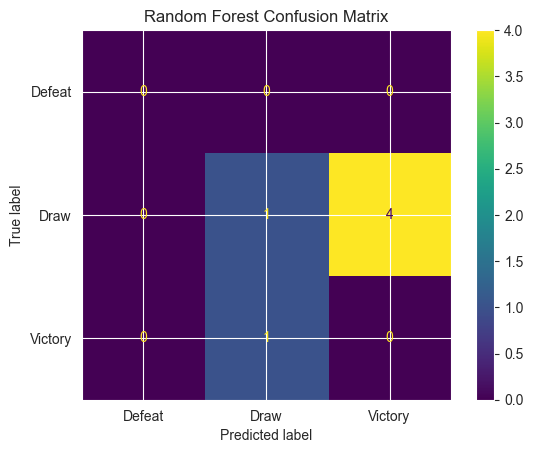

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced', random_state=42) # Use balanced class weights to handle class imbalances
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy: {:.2f}".format(accuracy_score(y_test, y_pred_rf)))
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))
ConfusionMatrixDisplay.from_estimator(
    rf, X_test, y_test, labels=[-1, 0, 1], display_labels=["Defeat", "Draw", "Victory"]
)

plt.title("Random Forest Confusion Matrix")
plt.show()

Reference:

RandomForestRegressor. (2025). Scikit-Learn. Retrieved November 15, 2025, from https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

Logistic Regression Accuracy: 0.50
Logistic Regression Classification Report:
               precision    recall  f1-score   support

          -1       0.67      1.00      0.80         2
           0       0.50      0.33      0.40         3
           1       0.00      0.00      0.00         1

    accuracy                           0.50         6
   macro avg       0.39      0.44      0.40         6
weighted avg       0.47      0.50      0.47         6



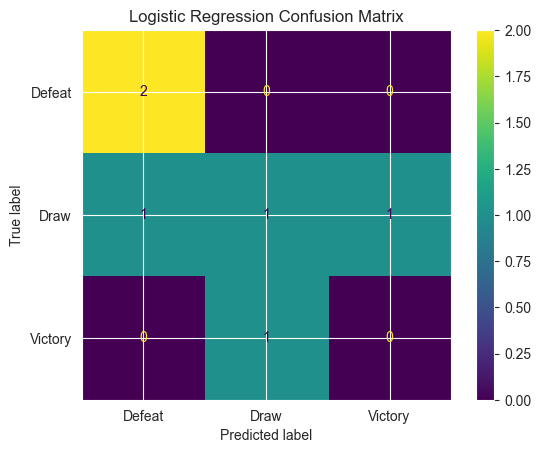

In [12]:
from sklearn.linear_model import LogisticRegression

# stratified split to maintain class distribution in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy: {:.2f}".format(accuracy_score(y_test, y_pred_lr)))
print("Logistic Regression Classification Report:\n", classification_report(y_test, y_pred_lr))

ConfusionMatrixDisplay.from_estimator(
    lr, X_test, y_test, labels=[-1, 0, 1], display_labels=["Defeat", "Draw", "Victory"] 
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

Reference:

LogisticRegression. (2025). Scikit-Learn. Retrieved November 15, 2025, from https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

3. Report and compare their results with those from SVM.

Looking at the SVM from question 1, the accuracy and classification report shows that the model correctly predicted the outcome for about 67% of the test samples. From the classification report, class 0 (draw) seems to have the most accurate percentage of precision, recall, and F-1 score - all stand at 80% - from 5 samples in the dataset. At the same token, class 1 (victory) all has precision / recall / F-1 score at 0, or the model basically has failed to correctly predict any victories for 1 Victory in the dataset. Also, the SVM visualization may not show the correct dots due to the fact it has been reduced down to 2D projections via Principal Component Analysis (PCA), so you can't have all 4 variables all listed on the visualization. Because of the reduction, there may be information that are not listed. Hence, this is a projection and may not be perfectly showcasing the separation of the classes as seen by the SVM in the original 4D space (Frost, n.d.). "Victory" seems to have some red dots in the red background, and "defeat" seemingly hang out in their blue region. The "Draw" option is all blank until we can pinpoint where the variable is during this tournmanet. 

Unfortunately, random forest regressor performs worse than SVM with accuracy score at 17%. For "draw", class 0 has 50% for precision, 20% of the recall rate, and F-1 score is 0.29. Additionally, class 1 (victory) has precision/recall/F1-score at 0.00. In other words, the model fails to predict any "victories" and strugged to identify "draws". After examining the confusion matrix, we have "defeat" (row 1) contains 0 samples in the test set (all values are 0). Next, "draw" or row 2 has 1 sample that was misclassified as "draw" (Should really be "draw" and expected as "draw). Also, 4 samples were misclassified as "victory" (should be "victory, predicted as "draw"). For "victory" or row 3, 1 sample was misclassified as Draw (should be "victory, predicted as "draw"). Lastly, it looks like 0 samples were correctedly predicted as "victory". It looks like there is no data on "defeat". It looks like the random forest regressor actually is struggling right now with acknowledging it has strugged to correctly classify both "Draws" and "Victory" in the training test split, which matches with the low accuracy and classification report.

For Logistic Regression, the accuracy score is much higher at 50%. "Defeat" (-1) has precision at 67%, recall at 1.00, and F-1 Score is 80%. For "Draw" (0) has precision at 50%, and recall at 0.33 plus F1-Score = 0.40. Finally, "victory" (1) has precision, recall, and F1 to be at 0.00 (no "victories" were to correctly predict ). Looking at the confusion matrix, "defeat" (-1) = 2 defeats were correctly predicted as defeat. "Draw" (0) practically has 1 right across the confusion matrix. Additionally, 1 "Victory" was predicted as "draw", and zero other "victories" were correctly predicted. This method isn't very good at predicting "Draws" and can't really identify "Victories", but it surely can predict "Defeats". Overall, the model has average or moderately accurate result (0.50), but it has significant trouble with "Draws" and "Victories."

Reference:

Frost, J. (n.d.). Principal Component Analysis Guide & Example. Statistics By Jim. https://statisticsbyjim.com/basics/principal-component-analysis/#:~:text=That's%20an%20ocean%20of%20data,That's%20much%20easier%20to%20understand!